In [1]:
from manim import *

Manim Community v0.18.0

In [60]:
%%manim -v WARNING -qm LimitOfXOverX


class LimitOfXOverX(Scene):
    def construct(self):
        # Axes setup
        axes = Axes(
            x_range=[-4, 4, 1],
            y_range=[0, 2, 0.5],
            x_length=8,
            y_length=4,
            axis_config={"include_tip": True}
        )

        # Function: f(x) = x/x (excluding 0)
        def x_over_x(x):
            return 1 if x != 0 else None

        # Plot excluding x=0
        graph = axes.plot(lambda x: x_over_x(x), color=BLUE, x_range=[-4, -0.1])
        graph2 = axes.plot(lambda x: x_over_x(x), color=BLUE, x_range=[0.1, 4])

        # Hole at x=0
        hole = Dot(axes.c2p(0, 1), color=RED)

        # Labels and titles
        title = Text("Limit of f(x) = x/x as x → 0", font_size=36).to_edge(UP)
        func_label = MathTex(r"f(x) = \frac{x}{x}, \quad x \ne 0").next_to(graph2, UP)
        limit_text = MathTex(r"\lim_{x \to 0} \frac{x}{x} = 1").to_edge(DOWN)

        # Build the animation
        self.play(Write(title))
        self.play(Create(axes))
        self.play(Create(graph), Create(graph2))
        self.play(FadeIn(hole), run_time=1)
        self.play(Write(func_label))
        self.wait(1)

        # Emphasize the hole
        self.play(hole.animate.scale(1.5).set_color(YELLOW))
        self.wait(1)

        # Show the limit conclusion
        self.play(Write(limit_text))
        self.wait(2)



(process:1762): GLib-GObject-WARNING **: 13:52:05.381: cannot unreference class of invalid (unclassed) type '(NULL)'


In [3]:
%%manim -v WARNING -qh  CurveSketching

class CurveSketching(Scene):
    def construct(self):
        # Divide the screen visually: left for text, right for graph
        left_text_area = Rectangle(width=5.5, height=7, color=GREY, fill_opacity=0).to_edge(LEFT)
        right_graph_area = Rectangle(width=5.5, height=7, color=GREY, fill_opacity=0).to_edge(RIGHT)
        # Uncomment next lines if you want to see the separation visually
        # self.add(left_text_area, right_graph_area)

        # Axes for y = x^2 graph (shifted to the right)
        axes = Axes(
            x_range=[-5, 5, 1],
            y_range=[-5, 5, 1],
            x_length=5,
            y_length=5,
            axis_config={"color": WHITE},
            tips=False
        ).to_edge(RIGHT).shift(LEFT * 0.5)
############################################################################################################################################################################################


        # Define the function y = x^2
        graph = axes.plot(lambda x: x**2, color=YELLOW)
        graph_label = axes.get_graph_label(graph, label="y = x^2", x_val=2.2, direction=UR)

        graph_copy1 = graph.copy().set_color(YELLOW)

        # STEP 1: Title and introduction text
        step1 = Text("Step 1: Understand the function", font_size=25, color=BLUE).to_edge(LEFT).shift(UP * 2)
        expl1 = Text("The function y = x² is of degree two \nso it represents a parabola", font_size=28).next_to(step1, DOWN, aligned_edge=LEFT)

        self.play(Write(step1))
        self.play(Write(expl1))
        self.wait(2)

        # Draw axes show graph of parabola could be among these.
        step2 = Text("parabola could be among these", font_size=28).next_to(expl1, DOWN, buff=0.8, aligned_edge=LEFT)
        self.play(Write(step2))
        self.play(Create(axes))
        self.play(Create(graph), run_time=3)
        self.play(Write(graph_label))

        # Shift the curve right by 1 unit and up by 2 units within the axes coordinate system
        shift_vector = axes.c2p(1, 2) - axes.c2p(0, 0)
        self.play(graph_copy1.animate.shift(shift_vector))
        # Change the original parabola color to grey
        self.play(graph.animate.set_color(GREY))
        
       

        shift_vector = axes.c2p(-3, -4) - axes.c2p(1, 2)
        graph_copy2 = graph_copy1.copy().set_color(YELLOW)
        self.play(graph_copy2.animate.shift(shift_vector))
        self.play(graph_copy1.animate.set_color(GREY))

        shift_vector = axes.c2p(-3, 5) - axes.c2p(-3, -4)
        graph_copy3 = graph_copy2.copy().set_color(YELLOW)
        self.play(graph_copy3.animate.shift(shift_vector))
        self.play(graph_copy2.animate.set_color(GREY))

        shift_vector = axes.c2p(2, -2) - axes.c2p(-3, 5)
        graph_copy4 = graph_copy3.copy().set_color(YELLOW)
        self.play(graph_copy4.animate.shift(shift_vector))
        self.play(graph_copy3.animate.set_color(GREY))

   

        # Stretch horizontally(making wider) and rotate around point (2,-2)
        self.play(graph_copy4.animate.stretch(2, dim=0))  # dim=0 means x-direction
        self.play(graph_copy4.animate.rotate(PI, about_point=axes.c2p(2,-2)), run_time=3)

        shift_vector = axes.c2p(0, 0) - axes.c2p(2, -2)
        self.play(graph_copy4.animate.shift(shift_vector))



        # Rotate around the origin of the AXES (not the screen)
        self.play(graph_copy4.animate.rotate(PI/2, about_point=axes.c2p(0, 0)), run_time=2)

        # Vertical line at x = 2, extend far above and below
        x_val = 2
        vertical_line = Line(
            start=axes.c2p(x_val, -1000),  # very low y
            end=axes.c2p(x_val, 1000),     # very high y
            color=BLUE
        )


        # Draw the vertical line
        self.play(Create(vertical_line))
        tex1 = Text("Definitely this can't be\n as it doesnot satisfy vertical line test", font_size=28).next_to(step2, DOWN, buff=0.8, aligned_edge=LEFT)
        self.play(Write(tex1))
        self.wait(1)
# #################################################################################################################################################################################################
        #Fade out every text up to now
        self.play(FadeOut(step1), FadeOut(expl1), FadeOut(step2) ,FadeOut(tex1))
        self.wait(1)


        tex2 = Text("First we do origin test", font_size=25, color=BLUE).to_edge(LEFT).shift(UP * 2)
        self.play(Write(tex2))
        self.wait(1)

        
        # Math equatiions for origin test
        eqs = [
            "f(x) = 0",
            "\\text{at } x = 0 \\Rightarrow f(0) = 0^2 = 0",
            "\\text{so the curve passes} \\\\ \\text{through the origin (0,0)}"
        ]

        m_eqs = [MathTex(e) for e in eqs]
        m_eqs[0].next_to(tex2, DOWN, buff=0.6, aligned_edge=LEFT)
        for i, eq in enumerate(m_eqs):
            if i > 0:
                eq.next_to(m_eqs[i-1], DOWN, buff=0.6, aligned_edge=LEFT)
            self.play(Write(eq))
            self.wait(0.5)

        #Fade out every text up to now
        self.play(FadeOut(tex2))
        for eq in m_eqs:
            self.play(FadeOut(eq))
        self.wait(1)

        tex3 = Text("Now we remove the curve\n that doesnot pass origin test\n and vertical line test", font_size=25, color=BLUE).to_edge(LEFT).shift(UP * 2)
        self.play(Write(tex3))  
        self.play(FadeOut(graph_copy1), FadeOut(graph_copy2),FadeOut(graph_copy3),FadeOut(graph_copy4),FadeOut(vertical_line))
        self.play(graph.animate.set_color(YELLOW))
        tex4 = Text("So the curves of f(x) = x^2 \ncould be among these  ", font_size=28).next_to(tex3, DOWN, buff=0.8, aligned_edge=LEFT)
        self.play(Write(tex4))

        graph_copy11 = graph.copy().set_color(BLUE)
        self.play(graph_copy11.animate.rotate(PI, about_point=axes.c2p(0, 0)), run_time=2)

        self.play(FadeOut(tex3), FadeOut(tex4))

        

        self.wait(2)


        
        
        

    # STEP 3: Plot some key points
        line1 = MathTex("\\text{Compairing } y = x^2 with,y = ax^2 + bx + c", font_size=30)
        self.play(Write(line1.to_edge(LEFT).shift(UP * 2)))
        line2 = MathTex("\\text{We get, a = 1, b = 0, c = 0}", font_size=30)
        self.play(Write(line2.next_to(line1, DOWN, buff=0.6, aligned_edge=LEFT)))
        expl3 = MathTex("\\text{Since $a > 0$, the parabola opens upwards}", font_size=30).next_to(line2, DOWN, buff=0.8, aligned_edge=LEFT)
        self.play(Write(expl3))

        self.wait(2)

        self.play(FadeOut(line1), FadeOut(line2), FadeOut(expl3))
        self.wait(1)
        expl4 = MathTex("\\text{This graph looks like\n the only possible option }", font_size=30).to_edge(LEFT).shift(UP * 2)
        self.play(Write(expl4))
        self.play(FadeOut(graph_copy11))


        line3 = MathTex("\\text{For Vertex, x =-b/2a = 0, y = 0,vertex = (0,0)}", font_size=30)
        self.play(Write(line3.next_to(expl4, DOWN, buff=0.6, aligned_edge=LEFT)))
        line4 = MathTex("\\text{For Domain = (-inf, +inf), Range = [0,+inf]}", font_size=30).next_to(line3, DOWN, buff=0.6, aligned_edge=LEFT)
        self.play(Write(line4))
        self.wait(1)

        self.play(FadeOut(expl4), FadeOut(line3), FadeOut(line4))
        self.wait(1)
        line5 = MathTex("\\text{It is not clear why not Streach and squezze!!!}", font_size=30).to_edge(LEFT).shift(UP * 2)
        self.play(Write(line5))
        self.wait(1)

        self.play(graph.animate.stretch(2, dim=0))
        self.play(graph.animate.stretch(0.2, dim=0))
        self.play(FadeOut(line5))
        self.wait(2)

        # Table data (x, y = x^2)

        data = [
            ["x", "y = x^2"],
            ["-2", "4"],
            ["-1", "1"],
            ["0", "0"],
            ["1", "1"],
            ["2", "4"]
        ]

        # Create the table
        table = Table(
            data,
            include_outer_lines=True,
            line_config={"color": WHITE},
            element_to_mobject=lambda e: MathTex(e)  # Math mode for proper rendering
        )


        # Scale and move to left half
        table.scale(0.8)
        table.to_edge(LEFT)  # Move entire table to the left side

        # Animate table creation
        self.play(Create(table))
        self.wait(2)

        


In [25]:
# %%manim -v WARNING -ql -i TableToParabola

# class TableToParabola(Scene):
#     def construct(self):
#         # --- Table Data ---
#         data = [
#             ["x", "y = x^2"],
#             ["-2", "4"],
#             ["-1", "1"],
#             ["0", "0"],
#             ["1", "1"],
#             ["2", "4"]
#         ]

#         # --- Create Table on Left ---
#         table = Table(
#             data,
#             include_outer_lines=True,
#             line_config={"color": WHITE},
#             element_to_mobject=lambda e: MathTex(e)
#         ).scale(0.8).to_edge(LEFT)

#         # --- Create Axes on Right ---
#         axes = Axes(
#             x_range=[-3, 3],
#             y_range=[0, 5],
#             x_length=5,
#             y_length=4,
#             axis_config={"color": GREY}
#         ).to_edge(RIGHT)

#         # --- Add labels ---
#         labels = axes.get_axis_labels(x_label="x", y_label="y")

#         # --- Create points for y = x^2 ---
#         points = [axes.coords_to_point(x, x**2) for x in [-2, -1, 0, 1, 2]]
#         dots = [Dot(p, color=YELLOW) for p in points]

#         # --- Graph of parabola ---
#         parabola = axes.plot(lambda x: x**2, color=BLUE)

#         # --- Animations ---
#         self.play(Create(table))
#         self.play(Create(axes), Write(labels))
#         self.wait(1)

#         # Plot dots one by one
#         for dot in dots:
#             self.play(FadeIn(dot, scale=0.5))
#             self.wait(0.3)

#         self.wait(1)

#         # Draw parabola through the points
#         self.play(Create(parabola), run_time=3)
#         self.wait(2)

In [4]:

%%manim -v WARNING -qh  TableToGraphAnimation
class TableToGraphAnimation(Scene):
    def construct(self):
        # --- Table data (x, y = x^2) ---
        data = [
            ["x", "y = x^2"],
            ["-2", "4"],
            ["-1", "1"],
            ["0", "0"],
            ["1", "1"],
            ["2", "4"]
        ]

        # --- Create Table (Left Side) ---
        table = Table(
            data,
            include_outer_lines=True,
            line_config={"color": WHITE},
            element_to_mobject=lambda e: MathTex(e)
        ).scale(0.8).to_edge(LEFT)

        # --- Create Axes (Right Side) ---
        axes = Axes(
            x_range=[-5, 5],
            y_range=[-5, 5],
            x_length=5,
            y_length=4,
            axis_config={"color": GREY}
        ).to_edge(RIGHT)
        labels = axes.get_axis_labels("x", "y")

        # --- Prepare graph data ---
        xy_values = [(-2,4), (-1,1), (0,0), (1,1), (2,4)]
        parabola = axes.plot(lambda x: x**2, color=BLUE)

        # --- Animate setup ---
        self.play(Create(table))
        self.play(Create(axes), Write(labels))
        self.wait(0.5)

        # --- Animate each (x, y) flying from table to graph ---
        dots = []
        for i, (x, y) in enumerate(xy_values, start=1):
            # Get cell positions (table row index starts at 1 for header)
            x_cell = table.get_cell((i+1, 1))  # x value cell
            y_cell = table.get_cell((i+1, 2))  # y value cell

            # Create small floating MathTex to animate
            x_val = MathTex(str(x))
            y_val = MathTex(str(y))

            # Place these texts on top of the corresponding table cells
            x_val.move_to(x_cell.get_center())
            y_val.move_to(y_cell.get_center())

            # Create the dot position on the graph
            point = axes.coords_to_point(x, y)
            dot = Dot(point, color=YELLOW)

            # Animate x and y flying to the graph point
            self.play(
                x_val.animate.move_to(point + LEFT*0.3),
                y_val.animate.move_to(point + UP*0.3),
                run_time=1.5
            )

            # Fade out texts and reveal the dot
            self.play(
                FadeOut(x_val),
                FadeOut(y_val),
                FadeIn(dot, scale=1.2),
                run_time=0.5
            )

            dots.append(dot)
            self.wait(0.5)

            # --- Draw parabola through points ---
        self.play(Create(parabola), run_time=3)
        self.wait(2)


# --- Group everything related to the graph ---
        graph_group = VGroup(axes, labels, parabola, *dots)

        # --- Move so that origin (0,0) is at the CENTER of frame ---
        origin_point = axes.coords_to_point(0, 0)
        shift_to_center = ORIGIN - origin_point

        self.play(
            graph_group.animate.shift(shift_to_center),
            FadeOut(table, shift=LEFT),
            run_time=2
        )


        # --- Final pause ---
        self.wait(2)

       



######################################################################################################################################################################################
#Final portion of the graph of parabola through shifting 

        # --- Explanatory text section (kept to left side) ---
        # Create a background box for text area (optional, helps visually separate)
        text_area = Rectangle(width=5.5, height=4, fill_opacity=0, stroke_opacity=0).to_edge(LEFT)

        tex0 = Text(
            "Now we sketch the graph of \n y = x^2 - 4x + 3",
            font_size=30,
            color=BLUE
        ).next_to(text_area.get_top(), DOWN, buff=0.5).align_to(text_area, LEFT)

        self.play(Write(tex0))
        self.wait(1.5)
        self.play(FadeOut(tex0))
        self.wait(0.5)

        # --- Step-by-step math explanation (kept to the left half) ---
        eqs = [
            r"y = x^2 - 4x + 3",
            r"\Rightarrow y = (x - 2)^2 - 1"
            #r"\text{So, the graph of } y = x^2 - 4x + 3 \\ \text{is the graph of } y = x^2 \\ \\ \text{shifted right by 2 units and down by 1 unit.}"
        ]

        m_eqs = [MathTex(e).scale(0.9) for e in eqs]

        # Position equations neatly under each other on the left half
        m_eqs[0].next_to(text_area.get_top(), UP, buff=1).align_to(text_area, LEFT)
        for i, eq in enumerate(m_eqs[1:], start=1):
            eq.next_to(m_eqs[i - 1], DOWN, buff=0.6, aligned_edge=LEFT)

        for eq in m_eqs:
            self.play(Write(eq))
            self.wait(1)
        

        text12 = Text(
            "So the graph y = x^2 \nis shifted right by 2 units \n and down by 1 unit.",
            font_size=30,
            color=YELLOW
        ).to_edge(LEFT)

        self.play(Write(text12))
        self.wait(1.5)
        self.play(FadeOut(text12))

        # --- Shift ONLY the parabola and dots (axes stay fixed) ---
        # Current vertex of y = x^2 in scene coordinates
        current_vertex = axes.coords_to_point(0, 0)

        # Target vertex of y = x^2 - 4x + 3 in scene coordinates
        target_vertex = axes.coords_to_point(2, -1)

        # Compute the exact shift vector
        shift_vector = target_vertex - current_vertex

        # Apply shift to parabola and dots only
        self.play(
            parabola.animate.shift(shift_vector),
            *[dot.animate.shift(shift_vector) for dot in dots],
            run_time=2
        )

        # --- Fade out equations ---
        self.play(*[FadeOut(eq) for eq in m_eqs])
        self.wait(1)


                ############################################################
                ############################################################
        # --- Reflect the graph about the y-axis ---
        self.wait(1)
        text_reflect = MathTex(r" f(x)= x^2 + 4x + 3 \Rightarrow f(-x) = x^2 - 4x +3", font_size=30, color=BLUE).to_edge(LEFT).shift(UP * 2)
        self.play(Write(text_reflect))
        self.wait(2)
        self.play(FadeOut(text_reflect))


        reflect_text = Text(
            "Now, let's reflect the\n graph about the y-axis.",
            font_size=30,
            color=YELLOW
        ).to_edge(LEFT)

        self.play(Write(reflect_text))
        self.wait(1.5)
        self.play(FadeOut(reflect_text))

        # --- Create a copy of the shifted parabola for transformation ---
        reflected_parabola = parabola.copy()
        reflected_dots = [dot.copy() for dot in dots]

        # --- Reflection transformation ---
        self.play(
            reflected_parabola.animate.scale([-1, 1, 1], about_point=axes.coords_to_point(0, 0)),
            *[
                dot.animate.scale([-1, 1, 1], about_point=axes.coords_to_point(0, 0))
                for dot in reflected_dots
            ],
            run_time=2
        )

        # --- Change color for clarity ---
        self.play(
            reflected_parabola.animate.set_color(GREEN),
            *[dot.animate.set_color(GREEN) for dot in reflected_dots],
            run_time=1
        )

        # --- Label old  equation ---
        new_eq1 = MathTex("y = x^2 - 4x + 3", color=BLUE).next_to(axes, UP).to_edge(RIGHT)
        self.play(Write(new_eq1))
        self.wait(0.5)

        # --- Label new equation ---
        new_eq2 = MathTex("y = x^2 + 4x + 3", color=GREEN).next_to(axes, UP).to_edge(LEFT)
        self.play(Write(new_eq2))
        self.wait(0.5)

         # --- Create an arrow from label to the reflected parabola ---
        # Let's point the arrow roughly near the vertex (-2, -1)
        vertex_point = axes.coords_to_point(4, 1)
        arrow1 = Arrow(
            start=new_eq1.get_bottom() + DOWN * 0.2,
            end=vertex_point + UP * 0.5,
            buff=0.1,
            color=BLUE
        )

        vertex_point = axes.coords_to_point(-4, 1)
        arrow2 = Arrow(
            start=new_eq2.get_bottom() + DOWN * 0.2,
            end=vertex_point + UP * 0.5,
            buff=0.1,
            color=GREEN
        )

        self.play(GrowArrow(arrow1))
        self.wait(1)
        self.play(GrowArrow(arrow2))
        self.wait(2)

[10/13/25 08:09:52] WARNING  --save_as_gif is deprecated, please use --format=gif instead!           ]8;id=292434;file:///Users/aakashkhanal/anaconda3/lib/python3.11/site-packages/manim/cli/render/commands.py\commands.py]8;;\:]8;id=815246;file:///Users/aakashkhanal/anaconda3/lib/python3.11/site-packages/manim/cli/render/commands.py#50\50]8;;\

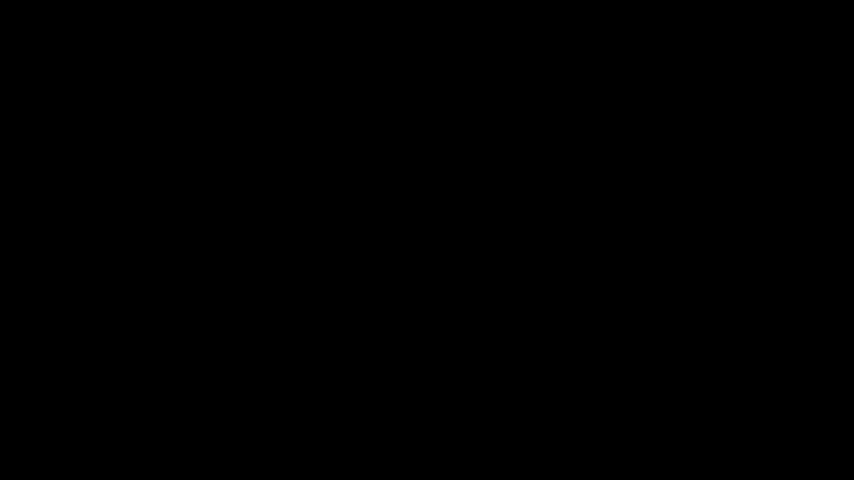

In [4]:
%%manim -v WARNING -ql -i CurveSketching_shifting
#Final portion of the graph of parabola through shifting 
class CurveSketching_shifting(Scene):

    def construct(self):

        # Divide the screen visually: left for text, right for graph
        left_text_area = Rectangle(width=5.5, height=7, color=GREY, fill_opacity=0).to_edge(LEFT)
        right_graph_area = Rectangle(width=5.5, height=7, color=GREY, fill_opacity=0).to_edge(RIGHT)
        # Uncomment next lines if you want to see the separation visually
        # self.add(left_text_area, right_graph_area)

        # Axes for y = x^2 graph (shifted to the right)
        axes = Axes(
            x_range=[-5, 5, 1],
            y_range=[-5, 5, 1],
            x_length=5,
            y_length=5,
            axis_config={"color": WHITE},
            tips=False
        ).to_edge(RIGHT).shift(LEFT * 0.5)

        # Math equatiions for origin test
        eqs = [
            "y = x^2 -4x +3",
            " \\Rightarrow y = (x-2)^2 - 1",
            "\\text{so the graph of $y = x^2 -4x +3$ } \\\\ \\text{is the graph of $y = x^2$ shifted} \\\\ \\text{right by 2 units and down by 1 unit}"
        ]

        m_eqs = [MathTex(e) for e in eqs]
        m_eqs[0].to_edge(UL)
        for i, eq in enumerate(m_eqs):
            if i > 0:
                eq.next_to(m_eqs[i-1], DOWN, buff=0.6, aligned_edge=LEFT)
            self.play(Write(eq))
            self.wait(1)

[10/12/25 10:16:25] WARNING  --save_as_gif is deprecated, please use --format=gif instead!           ]8;id=96144;file:///Users/aakashkhanal/anaconda3/lib/python3.11/site-packages/manim/cli/render/commands.py\commands.py]8;;\:]8;id=908537;file:///Users/aakashkhanal/anaconda3/lib/python3.11/site-packages/manim/cli/render/commands.py#50\50]8;;\

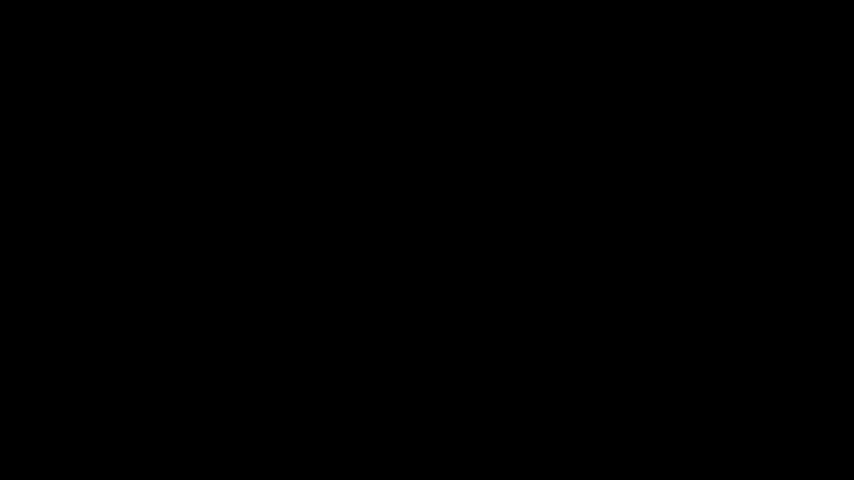

In [49]:
%%manim -v WARNING -ql -i MoveGraphKeepOriginal1

from manim import *

class MoveGraphKeepOriginal1(Scene):
    def construct(self):
        # Create axes
        axes = Axes(
            x_range=[-4, 4],
            y_range=[0, 8],
            axis_config={"color": GREY}
        )

        # Create the graph y = x^2
        parabola = axes.plot(lambda x: x**2, color=BLUE)
        label = axes.get_graph_label(parabola, label='y = x^2')

        self.play(Create(axes))
        self.play(Create(parabola), Write(label))
        self.wait(1)

        # Make a copy of the graph and move it
        parabola_copy = parabola.copy().set_color(BLUE)
        self.play(parabola_copy.animate.shift(RIGHT * 3 + DOWN * 2))

        # Change original parabola to grey
        self.play(parabola.animate.set_color(GREY))
        self.wait(1)

        # Fade out the copied parabola
        self.play(FadeOut(parabola_copy))
        self.wait(1)

[10/12/25 20:45:25] WARNING  --save_as_gif is deprecated, please use --format=gif instead!           ]8;id=207571;file:///Users/aakashkhanal/anaconda3/lib/python3.11/site-packages/manim/cli/render/commands.py\commands.py]8;;\:]8;id=274265;file:///Users/aakashkhanal/anaconda3/lib/python3.11/site-packages/manim/cli/render/commands.py#50\50]8;;\


(process:43807): GLib-GObject-WARNING **: 20:45:25.508: cannot unreference class of invalid (unclassed) type '(NULL)'


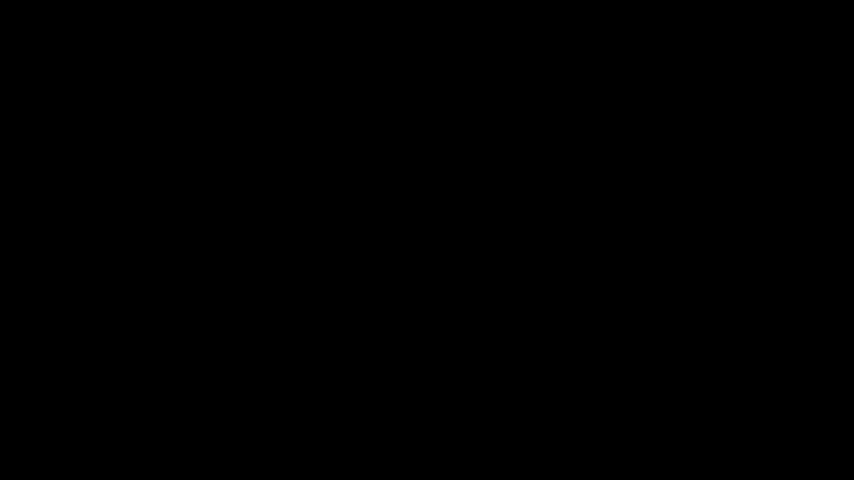

In [18]:
%%manim -v WARNING -ql -i NepaliText



class NepaliText(Scene):
    def construct(self):
        text = Text(
            "यो गणित धेरै रमाइलो छ!", 
            font="Devanagari Sangam MN"  # or "Mangal", "Kalimati", etc.
        )
        self.play(Write(text))
        self.wait(2)

[10/14/25 11:41:26] WARNING  --save_as_gif is deprecated, please use --format=gif instead!           ]8;id=178021;file:///Users/aakashkhanal/anaconda3/lib/python3.11/site-packages/manim/cli/render/commands.py\commands.py]8;;\:]8;id=725605;file:///Users/aakashkhanal/anaconda3/lib/python3.11/site-packages/manim/cli/render/commands.py#50\50]8;;\


(process:1923): GLib-GObject-WARNING **: 11:41:26.310: cannot unreference class of invalid (unclassed) type '(NULL)'


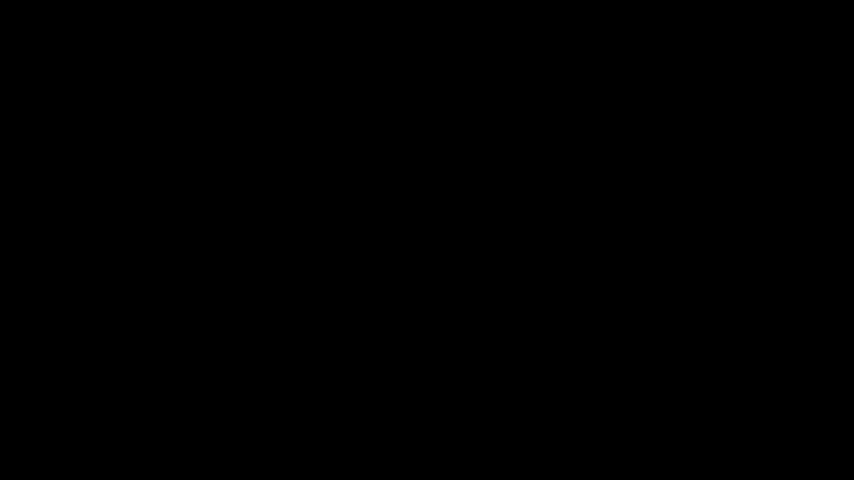

In [ ]:

%%manim -v WARNING -ql -i UnitCircleTrig
class UnitCircleTrig(Scene):
    def construct(self):
        # Title
        title = Text("Visualizing sin, cos, and tan in the Unit Circle", font_size=32, color=YELLOW)
        title.to_edge(UP)
        self.play(Write(title))
        self.wait(1)

        # Unit circle
        circle = Circle(radius=2, color=BLUE)
        circle.move_to(ORIGIN)
        self.play(Create(circle))

        # Axes
        axes = NumberPlane(
            x_range=[-3, 3, 1],
            y_range=[-3, 3, 1],
            background_line_style={"stroke_color": GREY, "stroke_opacity": 0.5}
        ).scale(1)
        self.play(Create(axes), run_time=2)

        # Angle tracker
        theta = ValueTracker(PI / 6)

        # Moving line (radius)
        radius_line = always_redraw(lambda:
            Line(ORIGIN, 2 * np.array([np.cos(theta.get_value()), np.sin(theta.get_value()), 0]), color=WHITE)
        )

        # Projections
        sine_line = always_redraw(lambda:
            Line(
                2 * np.array([np.cos(theta.get_value()), 0, 0]),
                2 * np.array([np.cos(theta.get_value()), np.sin(theta.get_value()), 0]),
                color=RED
            )
        )

        cosine_line = always_redraw(lambda:
            Line(
                ORIGIN,
                2 * np.array([np.cos(theta.get_value()), 0, 0]),
                color=GREEN
            )
        )

        # Tangent line
        tangent_line = always_redraw(lambda:
            Line(
                [2, -3, 0],
                [2, 3, 0],
                color=YELLOW,
                stroke_opacity=0.7
            )
        )

        # Tangent value visualization
        tangent_point = always_redraw(lambda:
            Dot(
                [2, 2 * np.tan(theta.get_value()), 0],
                color=YELLOW
            )
        )

        # Angle arc
        angle_arc = always_redraw(lambda:
            Arc(radius=0.5, start_angle=0, angle=theta.get_value(), color=PURPLE)
        )

        # Labels
        theta_label = always_redraw(lambda:
            MathTex(r"\theta", color=PURPLE).next_to(angle_arc, RIGHT, buff=SMALL_BUFF)
        )
        sin_label = always_redraw(lambda:
            MathTex(r"\sin(\theta)", color=RED).next_to(sine_line, LEFT, buff=0.2)
        )
        cos_label = always_redraw(lambda:
            MathTex(r"\cos(\theta)", color=GREEN).next_to(cosine_line, DOWN, buff=0.2)
        )
        tan_label = always_redraw(lambda:
            MathTex(r"\tan(\theta)", color=YELLOW).next_to(tangent_point, RIGHT, buff=0.2)
        )

        # Add all elements
        self.play(
            Create(radius_line),
            Create(sine_line),
            Create(cosine_line),
            Create(tangent_line),
            Create(angle_arc),
            Write(theta_label),
            Write(sin_label),
            Write(cos_label),
            Write(tan_label),
            Create(tangent_point),
        )

        self.wait(1)

        # Animate full rotation
        self.play(theta.animate.set_value(2 * PI), run_time=10, rate_func=linear)

        self.wait(2)


[10/14/25 11:47:29] WARNING  --save_as_gif is deprecated, please use --format=gif instead!           ]8;id=748604;file:///Users/aakashkhanal/anaconda3/lib/python3.11/site-packages/manim/cli/render/commands.py\commands.py]8;;\:]8;id=906730;file:///Users/aakashkhanal/anaconda3/lib/python3.11/site-packages/manim/cli/render/commands.py#50\50]8;;\

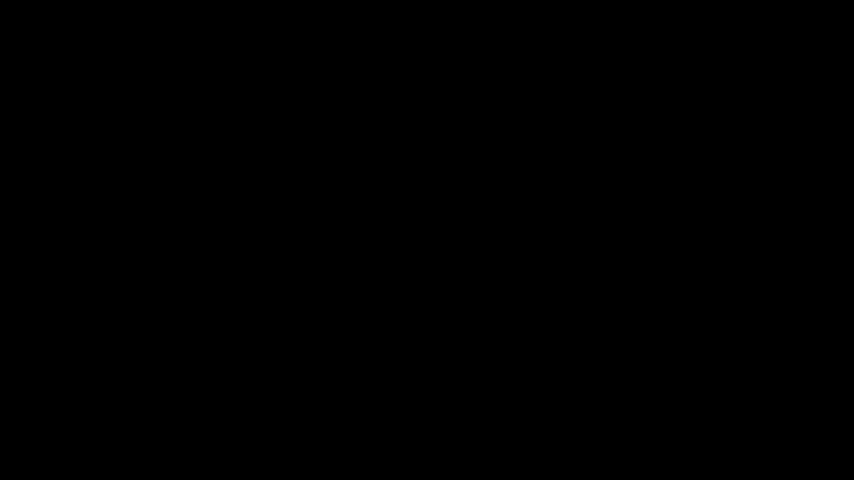

In [ ]:


%%manim -v WARNING -ql -i UnitCircleTangent


class UnitCircleTangent(Scene):
    def construct(self):
        # Title
        title = Text("Visualizing sin, cos, and tan in the Unit Circle", font_size=32, color=YELLOW)
        title.to_edge(UP)
        self.play(Write(title))

        # Unit circle
        circle = Circle(radius=2, color=BLUE)
        self.play(Create(circle))

        # Axes
        axes = NumberPlane(
            x_range=[-3, 3, 1],
            y_range=[-3, 3, 1],
            background_line_style={"stroke_color": GREY, "stroke_opacity": 0.5}
        )
        self.play(Create(axes))

        # Theta tracker
        theta = ValueTracker(PI / 6)

        # Moving radius (hypotenuse)
        radius_line = always_redraw(
            lambda: Line(
                ORIGIN, 
                2 * np.array([np.cos(theta.get_value()), np.sin(theta.get_value()), 0]),
                color=WHITE
            )
        )

        # Moving dot (end of radius)
        moving_dot = always_redraw(
            lambda: Dot(2 * np.array([np.cos(theta.get_value()), np.sin(theta.get_value()), 0]), color=WHITE)
        )

        # Projections (sine and cosine)
        sine_line = always_redraw(
            lambda: Line(
                2 * np.array([np.cos(theta.get_value()), 0, 0]),
                2 * np.array([np.cos(theta.get_value()), np.sin(theta.get_value()), 0]),
                color=RED
            )
        )

        cosine_line = always_redraw(
            lambda: Line(
                ORIGIN,
                2 * np.array([np.cos(theta.get_value()), 0, 0]),
                color=GREEN
            )
        )

        # Tangent line: always perpendicular to radius at moving dot
        tangent_line = always_redraw(lambda: 
            Line(
                2 * np.array([np.cos(theta.get_value()), np.sin(theta.get_value()), 0]) - 
                3 * np.array([-np.sin(theta.get_value()), np.cos(theta.get_value()), 0]),  # backward
                2 * np.array([np.cos(theta.get_value()), np.sin(theta.get_value()), 0]) + 
                3 * np.array([-np.sin(theta.get_value()), np.cos(theta.get_value()), 0]),  # forward
                color=YELLOW
            )
        )

        # Angle arc
        angle_arc = always_redraw(lambda:
            Arc(radius=0.4, start_angle=0, angle=theta.get_value(), color=PURPLE)
        )

        # Labels
        theta_label = always_redraw(lambda:
            MathTex(r"\theta", color=PURPLE).next_to(angle_arc, RIGHT, buff=SMALL_BUFF)
        )

        sin_label = always_redraw(lambda:
            MathTex(r"\sin(\theta)", color=RED).next_to(sine_line, LEFT, buff=0.2)
        )

        cos_label = always_redraw(lambda:
            MathTex(r"\cos(\theta)", color=GREEN).next_to(cosine_line, DOWN, buff=0.2)
        )

        # Add everything
        self.play(
            Create(radius_line),
            Create(moving_dot),
            Create(sine_line),
            Create(cosine_line),
            Create(tangent_line),
            Create(angle_arc),
            Write(theta_label),
            Write(sin_label),
            Write(cos_label),
        )

        self.wait(1)

        # Animate rotation
        self.play(theta.animate.set_value(2 * PI), run_time=10, rate_func=linear)

        self.wait(2)


        

In [ ]:
%%manim -v WARNING -ql -i UnitCircleTanCot
import numpy as np

class UnitCircleTanCot(Scene):
    def construct(self):
        # Title
        title = Text("Visualizing sin, cos, tan, and cot in the Unit Circle", font_size=32, color=YELLOW)
        title.to_edge(UP)
        self.play(Write(title))
        self.wait(1)
        # Axes and Circle
        axes = NumberPlane(
            x_range=[-5, 5, 1],
            y_range=[-5, 5, 1],
            background_line_style={"stroke_color": GREY, "stroke_opacity": 0.5}
        )
        circle = Circle(radius=2, color=BLUE)
        self.play(Create(axes), Create(circle))

        # Angle tracker
        theta = ValueTracker(PI / 6)

        # Moving radius (white)
        radius_line = always_redraw(lambda:
            Line(ORIGIN, 2 * np.array([np.cos(theta.get_value()), np.sin(theta.get_value()), 0]), color=WHITE)
        )

        # Moving dot on circle
        moving_dot = always_redraw(lambda:
            Dot(2 * np.array([np.cos(theta.get_value()), np.sin(theta.get_value()), 0]), color=WHITE)
        )

        # Sine & Cosine lines
        sine_line = always_redraw(lambda:
            Line(
                2 * np.array([np.cos(theta.get_value()), 0, 0]),
                2 * np.array([np.cos(theta.get_value()), np.sin(theta.get_value()), 0]),
                color=RED
            )
        )
        cosine_line = always_redraw(lambda:
            Line(
                ORIGIN,
                2 * np.array([np.cos(theta.get_value()), 0, 0]),
                color=GREEN
            )
        )

        # Tangent line at the moving dot
        tangent_line = always_redraw(lambda: 
            Line(
                2 * np.array([np.cos(theta.get_value()), np.sin(theta.get_value()), 0]) - 
                5 * np.array([-np.sin(theta.get_value()), np.cos(theta.get_value()), 0]),
                2 * np.array([np.cos(theta.get_value()), np.sin(theta.get_value()), 0]) + 
                5 * np.array([-np.sin(theta.get_value()), np.cos(theta.get_value()), 0]),
                color=YELLOW
            )
        )

        # Helper function to find intersections
        def line_intersection(p, v, axis="x"):
            # p = point on line, v = direction vector
            # Axis lines: x-axis (y=0), y-axis (x=0)
            if axis == "x":
                t = -p[1]/v[1]
            else:
                t = -p[0]/v[0]
            return p + t * v

        # Tangent segment down to x-axis (tan θ)
        tan_segment = always_redraw(lambda: 
            Line(
                2 * np.array([np.cos(theta.get_value()), np.sin(theta.get_value()), 0]),
                line_intersection(
                    2 * np.array([np.cos(theta.get_value()), np.sin(theta.get_value()), 0]),
                    np.array([-np.sin(theta.get_value()), np.cos(theta.get_value()), 0]),
                    axis="x"
                ),
                color=YELLOW
            )
        )

        # Tangent segment to y-axis (cot θ)
        cot_segment = always_redraw(lambda: 
            Line(
                2 * np.array([np.cos(theta.get_value()), np.sin(theta.get_value()), 0]),
                line_intersection(
                    2 * np.array([np.cos(theta.get_value()), np.sin(theta.get_value()), 0]),
                    np.array([-np.sin(theta.get_value()), np.cos(theta.get_value()), 0]),
                    axis="y"
                ),
                color=ORANGE
            )
        )

        # Angle arc
        angle_arc = always_redraw(lambda:
            Arc(radius=0.4, start_angle=0, angle=theta.get_value(), color=PURPLE)
        )

        theta_label = always_redraw(lambda:
            MathTex(r"\theta", color=PURPLE).next_to(angle_arc, RIGHT, buff=SMALL_BUFF)
        )

        # Labels
        sin_label = always_redraw(lambda:
            MathTex(r"\sin\theta", color=RED).next_to(sine_line, LEFT, buff=0.2)
        )
        cos_label = always_redraw(lambda:
            MathTex(r"\cos\theta", color=GREEN).next_to(cosine_line, DOWN, buff=0.2)
        )
        tan_label = always_redraw(lambda:
            MathTex(r"\tan\theta", color=YELLOW).next_to(tan_segment, DOWN, buff=0.2)
        )
        cot_label = always_redraw(lambda:
            MathTex(r"\cot\theta", color=ORANGE).next_to(cot_segment, LEFT, buff=0.2)
        )

        # Add everything
        self.play(
            Create(radius_line),
            Create(moving_dot),
            Create(sine_line),
            Create(cosine_line),
            Create(tangent_line),
            Create(tan_segment),
            Create(cot_segment),
            Create(angle_arc),
            Write(theta_label),
            Write(sin_label),
            Write(cos_label),
            Write(tan_label),
            Write(cot_label)
        )
        self.wait(1)

        # Animate rotation (avoiding discontinuities)
        self.play(theta.animate.set_value(PI/2 - 0.1), run_time=4)
        self.play(theta.animate.set_value(PI - 0.1), run_time=4)
        self.play(theta.animate.set_value(3*PI/2 - 0.1), run_time=4)
        self.play(theta.animate.set_value(2*PI - 0.1), run_time=4)
        self.wait(2)
